# DS Automation Assignment

Using our either our original churn data from week 1 or our prepped churn data from week 2:
- use pycaret or TPOT find an ML algorithm that performs best on the data
    - Choose a metric you think is best to use for finding the best model; by default, it is accuracy but it could be AUC, precision, recall, etc. The week 3 FTE has some information on these different metrics.
- save the model to disk
- create a Python script/file/module with a function that takes a pandas dataframe as an input and returns the probability of churn for each row in the dataframe
    - your Python file/function should print out the predictions for new data (new_churn_data.csv)
    - the true values for the new data are [1, 0, 0, 1, 0] if you're interested
- test your Python module and function with the new data, new_churn_data.csv
- upload this Jupyter Notebook and Python file and requirements.txt files to a GitHub repository
- write a short summary of the process and results in your GitHub README.md file.
- turn in a link to the repository in the week 5 assignment dropbox.

*Optional* challenges:
- return the probability of churn for each new prediction, and the percentile where that prediction is in the distribution of probability predictions from the training dataset (e.g. a high probability of churn like 0.78 might be at the 90th percentile)
- use other autoML packages, such as H2O, MLBox, etc, and compare performance and features with pycaret
- create a class in your Python module to hold the functions that you created
- accept user input to specify a file using a tool such as Python's `input()` function, the `click` package for command-line arguments, or a GUI
- Use the unmodified churn data (new_unmodified_churn_data.csv) in your Python script. This will require adding the same preprocessing steps from week 2 since this data is like the original unmodified dataset from week 1.

In [7]:
import sys
!{sys.executable} -m pip install pandas

!pip install pandas 
import pandas as pd 

df=pd.read_csv('churn_data.csv',index_col='customerID') 
df.head(10)

,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,
7590-VHVEG,1,No,Month-to-month,Electronic check,29.85,29.85,No
5575-GNVDE,34,Yes,One year,Mailed check,56.95,1889.50,No
3668-QPYBK,2,Yes,Month-to-month,Mailed check,53.85,108.15,Yes
7795-CFOCW,45,No,One year,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,2,Yes,Month-to-month,Electronic check,70.70,151.65,Yes
9305-CDSKC,8,Yes,Month-to-month,Electronic check,99.65,820.50,Yes
1452-KIOVK,22,Yes,Month-to-month,Credit card (automatic),89.10,1949.40,No
6713-OKOMC,10,No,Month-to-month,Mailed check,29.75,301.90,No
7892-POOKP,28,Yes,Month-to-month,Electronic check,104.80,3046.05,Yes


In [8]:
df.info() #Summary of our data, datatypes, number of columns and rows etc.

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7043 non-null   int64  
 1   PhoneService    7043 non-null   object 
 2   Contract        7043 non-null   object 
 3   PaymentMethod   7043 non-null   object 
 4   MonthlyCharges  7043 non-null   float64
 5   TotalCharges    7032 non-null   float64
 6   Churn           7043 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 440.2+ KB


In [9]:
!pip install PyCaret

In [10]:
#Fix to numpy error for code below
import sys
!{sys.executable} -m pip uninstall numpy -y
!{sys.executable} -m pip install numpy==1.26.4
!{sys.executable} -m pip install --upgrade pycaret

Found existing installation: numpy 1.26.4

You can safely remove it manually.
You can safely remove it manually.



Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached pandas-2.1.4-cp310-cp310-win_amd64.whl.metadata (18 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached pyod-2.0.6-py3-none-any.whl.metadata (46 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached category_encoders-2.8.1-py3-none-any.whl.metadata (7.9 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached numba-0.63.1-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
  Using cached importlib_metadata-8.7.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached nbformat-5.10.4-py

  You can safely remove it manually.
  You can safely remove it manually.


In [11]:
from pycaret.classification import ClassificationExperiment #Importing the necessary PyCaret tolls needed to create,load and use classification models
from pycaret.classification import load_model, predict_model

In [12]:
automl = ClassificationExperiment() #setting up a new Pycaret Classification ecperiment object and assigning it to the variable automl 

In [13]:
automl.setup(df, target='Churn')

,Description,Value
0,Session id,1928
1,Target,Churn
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(7043, 7)"
5,Transformed data shape,"(7043, 12)"
6,Transformed train set shape,"(4930, 12)"
7,Transformed test set shape,"(2113, 12)"
8,Numeric features,3
9,Categorical features,3


In [14]:
automl

In [15]:
best_model=automl.compare_models() #Running the autoML to find the best model

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.7925,0.8337,0.7925,0.7814,0.7831,0.4257,0.4324,0.0370
lr,Logistic Regression,0.7909,0.8298,0.7909,0.7801,0.7819,0.4235,0.4296,0.4630
gbc,Gradient Boosting Classifier,0.7895,0.8320,0.7895,0.7769,0.7783,0.4109,0.4192,0.0680
lda,Linear Discriminant Analysis,0.7862,0.8202,0.7862,0.7767,0.7791,0.4193,0.4233,0.0150
ridge,Ridge Classifier,0.7836,0.8202,0.7836,0.7685,0.7687,0.3816,0.3936,0.0150
lightgbm,Light Gradient Boosting Machine,0.7832,0.8204,0.7832,0.7712,0.7739,0.4020,0.4075,0.0760
knn,K Neighbors Classifier,0.7604,0.7376,0.7604,0.7435,0.7467,0.3258,0.3338,0.1710
rf,Random Forest Classifier,0.7600,0.7834,0.7600,0.7497,0.7532,0.3525,0.3552,0.0720
et,Extra Trees Classifier,0.7471,0.7591,0.7471,0.7391,0.7422,0.3281,0.3294,0.0620
dummy,Dummy Classifier,0.7347,0.5000,0.7347,0.5398,0.6223,0.0000,0.0000,0.0150


In [16]:
best_model #Displaying the best model found by autoML

AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=1928)

In [17]:
automl.evaluate_model(best_model) #Evaluating out best model

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

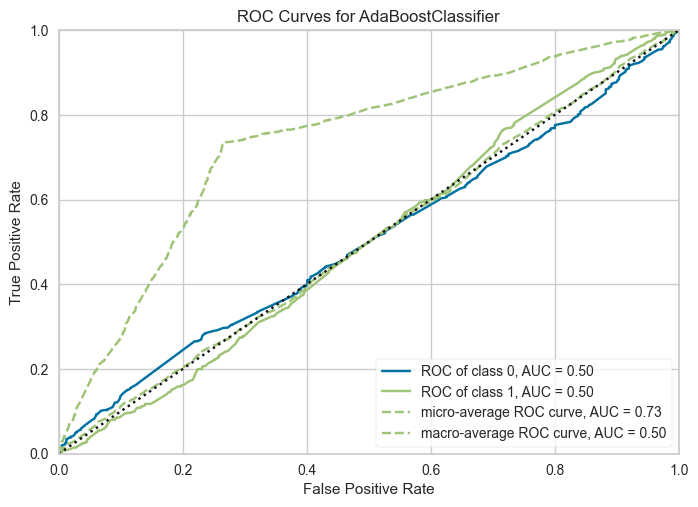

In [ ]:
automl.plot_model(best_model) #plotting the best model

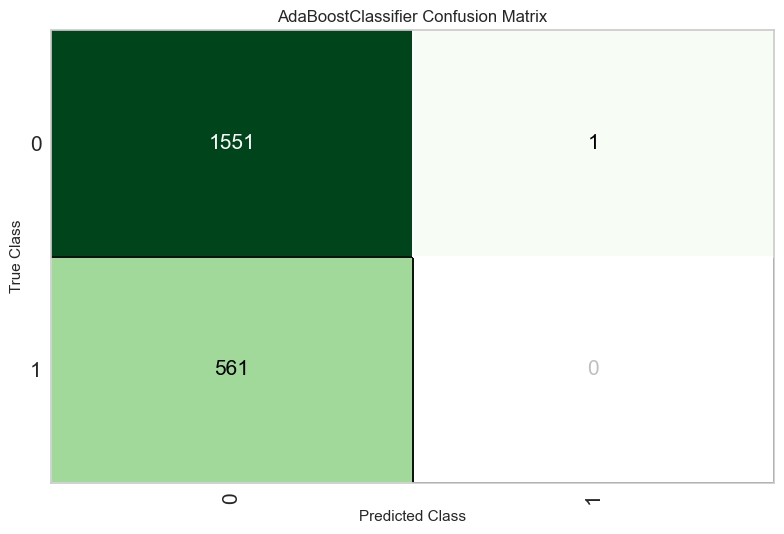

In [ ]:
automl.plot_model(best_model, plot='confusion_matrix')
#1551 classes correctly predicted as 0 and 561 classes correctly predicted as 1.

In [20]:
df.iloc[-2:-1].shape

(1, 7)

In [21]:
automl.predict_model(best_model, data=df.iloc[-2:-1]) # Predicting the class of the last row of our data using the best model found by autoML(Logistic Regression)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000


,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,prediction_label,prediction_score
customerID,,,,,,,,,
8361-LTMKD,4,Yes,Month-to-month,Mailed check,74.400002,306.600006,Yes,No,0.5058


In [22]:
predictions = automl.predict_model(best_model, data=df)#Prediciton fot the whole dataset

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.7346,0.4941,0.7346,0.6725,0.6228,0.0010,0.0127


In [23]:
predictions.head() #Predictions for the first 5 columns of our dataset

,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,prediction_label,prediction_score
customerID,,,,,,,,,
7590-VHVEG,1,No,Month-to-month,Electronic check,29.850000,29.850000,No,No,0.5050
5575-GNVDE,34,Yes,One year,Mailed check,56.950001,1889.500000,No,No,0.5050
3668-QPYBK,2,Yes,Month-to-month,Mailed check,53.849998,108.150002,Yes,No,0.5058
7795-CFOCW,45,No,One year,Bank transfer (automatic),42.299999,1840.750000,No,No,0.5045
9237-HQITU,2,Yes,Month-to-month,Electronic check,70.699997,151.649994,Yes,No,0.5063


In [24]:
predictions #Predictions for all the rows of our dataset

,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,prediction_label,prediction_score
customerID,,,,,,,,,
7590-VHVEG,1,No,Month-to-month,Electronic check,29.850000,29.850000,No,No,0.5050
5575-GNVDE,34,Yes,One year,Mailed check,56.950001,1889.500000,No,No,0.5050
3668-QPYBK,2,Yes,Month-to-month,Mailed check,53.849998,108.150002,Yes,No,0.5058
7795-CFOCW,45,No,One year,Bank transfer (automatic),42.299999,1840.750000,No,No,0.5045
9237-HQITU,2,Yes,Month-to-month,Electronic check,70.699997,151.649994,Yes,No,0.5063
...,...,...,...,...,...,...,...,...,...
6840-RESVB,24,Yes,One year,Mailed check,84.800003,1990.500000,No,No,0.5056
2234-XADUH,72,Yes,One year,Credit card (automatic),103.199997,7362.899902,No,No,0.5056
4801-JZAZL,11,No,Month-to-month,Electronic check,29.600000,346.450012,No,No,0.5058


In [25]:
#Saving and loading our best model
automl.save_model(best_model, 'pycaret_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['tenure', 'MonthlyCharges',
                                              'TotalCharges'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,...
                                     include=['Contract', 'PaymentMethod'],
                                     transformer=OneHotEncoder(cols=['Contract',
                                                       

In [26]:
#Loading the model we just saved
new_pycaret = ClassificationExperiment()
loaded_model = new_pycaret.load_model('pycaret_model')

Transformation Pipeline and Model Successfully Loaded


In [27]:
#New prediction using the loaded model
new_pycaret.predict_model(loaded_model, df.iloc[-2:-1])

,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,prediction_label,prediction_score
customerID,,,,,,,,,
8361-LTMKD,4,Yes,Month-to-month,Mailed check,74.400002,306.600006,Yes,No,0.5058


In [28]:
! pip freeze > requirements.txt